# 🏦 Bank Customer Churn Prediction using Decision Tree and Random Forest

This notebook solves the full project workflow and includes answers to all 216 questions.

In [1]:
# Cell 1: Import libraries and load project helpers.
from pathlib import Path
import sys, json, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import get_data_path, PROCESSED_DATA_PATH, MODEL_PATH, REPORTS_DIR, IMAGES_DIR
from src.preprocess import load_raw_data, clean_data, get_feature_target

print("Project root:", PROJECT_ROOT)
print("CSV path:", get_data_path())

Project root: D:\bank-customer-churn-prediction-complete\bank-customer-churn-prediction
CSV path: D:\bank-customer-churn-prediction-complete\bank-customer-churn-prediction\Bank_churn.csv


In [2]:
# Cell 2: Load raw data and show row/column count.
raw_df = load_raw_data(get_data_path())
print("Raw rows and columns:", raw_df.shape)
display(raw_df.head())
display(pd.DataFrame({"column": raw_df.columns, "dtype": raw_df.dtypes.astype(str)}))

Raw rows and columns: (165034, 14)


,id,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Rating,Exited,"Geography:str,Gender:str"
0,0.0,15674932.0,"O,k{wudilic_-huk>wu_",668.0,33.0,3.0,0.00,2.0,1.0,0.0,181449.97,-3,0,"{'Geography': 'Paris-France','Gender': 'Male'}"
1,1.0,15749177.0,"O{kwudi""li#%%'oli=-sa",627.0,33.0,1.0,0.00,2.0,1.0,1.0,49503.5,0,0,"{'Geography': 'Paris-France','Gender': 'Male'}"
2,2.0,15694510.0,Hsueh,678.0,40.0,10.0,0.00,2.0,1.0,0.0,184866.69,1,0,"{'Geography': 'Paris-France','Gender': 'Male'}"
3,3.0,15741417.0,"Kao,]?>?%]@",581.0,34.0,2.0,148882.54,1.0,1.0,1.0,84560.88,-4,0,"{'Geography': 'Paris-France','Gender': 'Male'}"
4,4.0,15766172.0,Ch-i]emen'-am,716.0,33.0,5.0,0.00,2.0,1.0,1.0,15068.83,-1,0,"{'Geography': 'Madrid-Spain','Gender': 'Male'}"


,column,dtype
id,id,float64
CustomerId,CustomerId,float64
Surname,Surname,str
CreditScore,CreditScore,float64
Age,Age,str
Tenure,Tenure,float64
Balance,Balance,float64
NumOfProducts,NumOfProducts,float64
HasCrCard,HasCrCard,float64
IsActiveMember,IsActiveMember,float64


In [3]:
# Cell 3: Clean data and save processed CSV.
df = clean_data(raw_df)
PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(PROCESSED_DATA_PATH, index=False)
print("Cleaned rows and columns:", df.shape)
display(df.head())
display(df.isna().sum().to_frame("missing_values"))

Cleaned rows and columns: (165031, 12)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Rating,Exited,Geography,Gender
0,668.0,33.0,3.0,0.00,2.0,1.0,0.0,181449.97,-3,0,Paris-France,Male
1,627.0,33.0,1.0,0.00,2.0,1.0,1.0,49503.50,0,0,Paris-France,Male
2,678.0,40.0,10.0,0.00,2.0,1.0,0.0,184866.69,1,0,Paris-France,Male
3,581.0,34.0,2.0,148882.54,1.0,1.0,1.0,84560.88,-4,0,Paris-France,Male
4,716.0,33.0,5.0,0.00,2.0,1.0,1.0,15068.83,-1,0,Madrid-Spain,Male


,missing_values
CreditScore,370
Age,6592
Tenure,4707
Balance,4041
NumOfProducts,5521
HasCrCard,2843
IsActiveMember,3525
EstimatedSalary,4577
Rating,0
Exited,0


In [4]:
# Cell 4: Notebook filter option for rows and columns.
# Change these variables whenever you want to inspect a segment.
selected_geography = None  # Example: "Paris-France"
selected_gender = None     # Example: "Male"
selected_exited = None     # Example: 1 for churned customers
row_limit = 10
columns_to_show = df.columns.tolist()

filtered_df = df.copy()
if selected_geography is not None:
    filtered_df = filtered_df[filtered_df["Geography"] == selected_geography]
if selected_gender is not None:
    filtered_df = filtered_df[filtered_df["Gender"] == selected_gender]
if selected_exited is not None:
    filtered_df = filtered_df[filtered_df["Exited"] == selected_exited]

print("Filtered rows and columns:", filtered_df.shape)
display(filtered_df[columns_to_show].head(row_limit))

Filtered rows and columns: (165031, 12)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Rating,Exited,Geography,Gender
0,668.0,33.0,3.0,0.00,2.0,1.0,0.0,181449.97,-3,0,Paris-France,Male
1,627.0,33.0,1.0,0.00,2.0,1.0,1.0,49503.50,0,0,Paris-France,Male
2,678.0,40.0,10.0,0.00,2.0,1.0,0.0,184866.69,1,0,Paris-France,Male
3,581.0,34.0,2.0,148882.54,1.0,1.0,1.0,84560.88,-4,0,Paris-France,Male
4,716.0,33.0,5.0,0.00,2.0,1.0,1.0,15068.83,-1,0,Madrid-Spain,Male
5,588.0,36.0,4.0,131778.58,1.0,1.0,0.0,136024.31,-1,1,Berlin-Germany,Male
6,593.0,30.0,8.0,144772.69,1.0,1.0,0.0,29792.11,-4,0,Paris-France,Female
7,678.0,37.0,1.0,138476.41,1.0,1.0,0.0,106851.60,-2,0,Madrid-Spain,Male
8,676.0,43.0,4.0,0.00,2.0,1.0,0.0,142917.13,3,0,Paris-France,Male
9,583.0,40.0,4.0,81274.33,1.0,1.0,1.0,170843.07,1,0,Berlin-Germany,Male


In [5]:
# Cell 5: EDA and churn-rate analysis.
print("Overall churn rate:", round(df["Exited"].mean() * 100, 2), "%")
display(df["Exited"].value_counts().rename(index={0:"Stayed", 1:"Churned"}))
display(df.groupby("Geography")["Exited"].agg(["count", "mean"]).sort_values("mean", ascending=False))
display(df.groupby("Gender")["Exited"].agg(["count", "mean"]).sort_values("mean", ascending=False))
display(df.groupby("IsActiveMember")["Exited"].agg(["count", "mean"]))
display(df.groupby("NumOfProducts")["Exited"].agg(["count", "mean"]).sort_values("mean", ascending=False))

Overall churn rate: 21.16 %


Exited
Stayed     130110
Churned     34921
Name: count, dtype: int64

,count,mean
Geography,,
Berlin-Germany,34461,0.379095
Unknown,745,0.200000
Madrid-Spain,36050,0.172178
Paris-France,93775,0.165300


,count,mean
Gender,,
Female,68319,0.279366
Unknown,8215,0.216555
Male,88497,0.158830


,count,mean
IsActiveMember,,
0.0,81129,0.297021
1.0,80377,0.125110


,count,mean
NumOfProducts,,
3.0,2788,0.883070
4.0,461,0.874187
1.0,74732,0.347067
2.0,81529,0.060212


In [6]:
# Cell 6: Prepare features and train-test split.
from sklearn.model_selection import train_test_split
X, y, numeric_features, categorical_features = get_feature_target(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print("X shape:", X.shape)
print("Train rows:", len(X_train), "Test rows:", len(X_test))
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

X shape: (165031, 11)
Train rows: 132024 Test rows: 33007
Numeric features: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Rating']
Categorical features: ['Geography', 'Gender']


In [7]:
# Cell 7: Explain Gini Impurity with the dataset churn ratio.
# Formula: Gini = 1 - sum(p_i^2)
churn_p = y.mean()
stay_p = 1 - churn_p
gini = 1 - (stay_p**2 + churn_p**2)
print("Stay probability:", round(stay_p, 4))
print("Churn probability:", round(churn_p, 4))
print("Root Gini impurity:", round(gini, 4))

Stay probability: 0.7884
Churn probability: 0.2116
Root Gini impurity: 0.3337


In [8]:
# Cell 8: Load saved model comparison created by src/train.py.
metrics = pd.read_csv(REPORTS_DIR / "model_comparison.csv")
display(metrics)
print("Best F1 model:", metrics.sort_values("f1_score", ascending=False).iloc[0]["model"])
print("Best ROC-AUC model:", metrics.sort_values("roc_auc", ascending=False).iloc[0]["model"])

,model,train_accuracy,test_accuracy,precision,recall,f1_score,roc_auc,overfit_gap_accuracy
0,Decision Tree - Gini,0.806262,0.803587,0.524658,0.763173,0.621828,0.869526,0.002675
1,Decision Tree - Entropy,0.805301,0.802375,0.522658,0.761312,0.619805,0.870240,0.002925
2,Random Forest,0.800923,0.797104,0.513534,0.779639,0.619207,0.869992,0.003819
3,Tuned Random Forest,0.799658,0.795649,0.511222,0.779496,0.617479,0.869517,0.004008


Best F1 model: Decision Tree - Gini
Best ROC-AUC model: Decision Tree - Entropy


C:\Users\Alok Agarwal\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.9.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Alok Agarwal\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Alok Agarwal\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying

              precision    recall  f1-score   support

      Stayed       0.93      0.81      0.87     26023
     Churned       0.52      0.76      0.62      6984

    accuracy                           0.80     33007
   macro avg       0.73      0.79      0.74     33007
weighted avg       0.84      0.80      0.82     33007



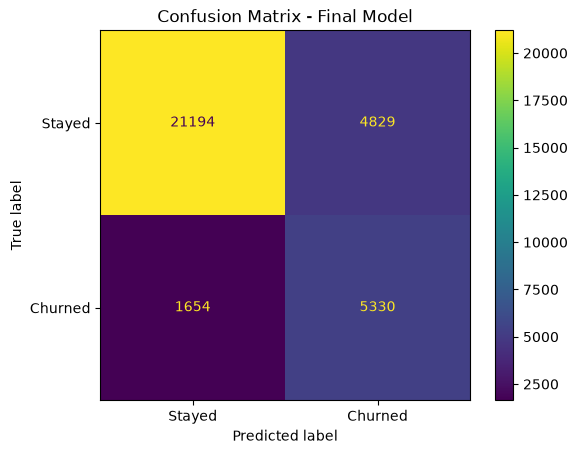

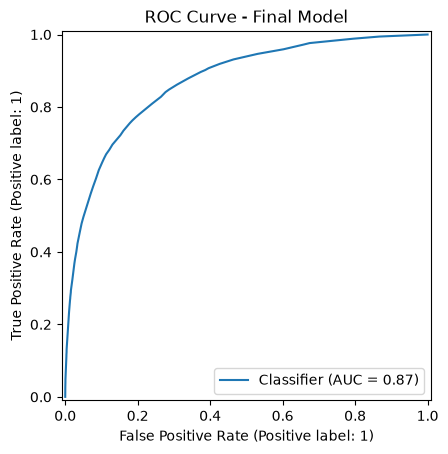

In [9]:
# Cell 9: Load final saved model and evaluate it again.
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay
model = joblib.load(MODEL_PATH)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["Stayed", "Churned"]))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Stayed", "Churned"])
plt.title("Confusion Matrix - Final Model")
plt.show()
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve - Final Model")
plt.show()

,feature,importance
0,Age,0.433841
1,NumOfProducts,0.363451
2,IsActiveMember,0.095916
3,Balance,0.073118
4,Geography_Berlin-Germany,0.023424
5,Gender_Female,0.005176
6,Gender_Male,0.005053
7,EstimatedSalary,0.000019
8,HasCrCard,0.000002
9,Tenure,0.000000


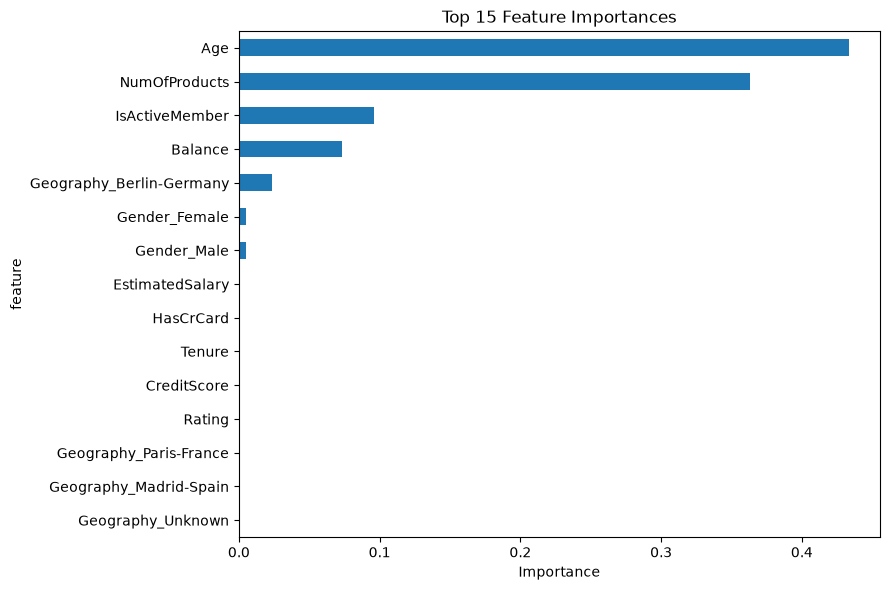

In [10]:
# Cell 10: Feature importance report.
feature_importance = pd.read_csv(REPORTS_DIR / "feature_importance.csv")
display(feature_importance.head(15))
feature_importance.head(15).iloc[::-1].plot(kind="barh", x="feature", y="importance", legend=False, figsize=(9,6))
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Complete Answers to All 216 Bank Customer Churn Project Questions

> Verified against the current project pipeline and artifacts on 22 September 2026. 
> Current cleaned data: 165,031 rows × 12 columns. Final saved model: Decision Tree - Gini.

## Problem statement

### 1. What is the main business problem this project is trying to solve?

Identify customers likely to close or leave their bank relationship early enough for the bank to intervene with a targeted retention action.

### 2. Why is customer churn prediction important for a bank?

Churn destroys future fee, interest, deposit, and cross-sell revenue, while replacing a customer usually requires additional acquisition and onboarding spending.

### 3. What does the target column Exited represent?

`Exited=1` means the customer churned; `Exited=0` means the customer stayed.

### 4. Is this a regression or classification problem? Why?

It is binary classification because the outcome has two discrete classes rather than a continuous numeric value.

### 5. What business decision can the bank make after predicting churn?

The bank can rank customers by churn probability, prioritize valuable high-risk customers, and select an appropriate contact or offer.

## Dataset overview

### 6. How many rows and columns are present in the dataset?

The raw CSV contains 165,034 rows and 14 columns. After parsing, removing identity fields, and removing three duplicate modeling rows, the cleaned data contains 165,031 rows and 12 columns.

### 7. What are the input features and what is the target variable?

The 11 inputs are CreditScore, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, Rating, Geography, and Gender. The target is Exited.

### 8. Which columns are numerical and which columns are categorical?

The nine numeric features are CreditScore, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, and Rating. Geography and Gender are categorical.

### 9. Are there any columns that should not be used for model training, such as customer ID or surname?

Yes. `id`, `CustomerId`, and `Surname` are identity/high-cardinality fields and are excluded. The combined source field is also removed after Geography and Gender are extracted.

### 10. What does each important column mean, such as CreditScore, Age, Balance, NumOfProducts, and IsActiveMember?

CreditScore describes creditworthiness; Age is customer age; Balance is account balance; NumOfProducts is the number of bank products; and IsActiveMember indicates recent/ongoing engagement.

## Data cleaning

### 11. Are there any missing values in the dataset?

Yes. Missing values include 7,186 IDs, 7,526 CustomerIds, 3,917 surnames, 370 credit scores, 5,599 ages, 4,707 tenures, 4,041 balances, 5,521 product counts, 2,843 card flags, 3,525 activity flags, and 4,377 salaries. The model pipeline imputes usable feature values.

### 12. Are there any duplicate rows?

The raw rows have no exact duplicates because identity fields differ. After identity removal, three duplicate modeling rows are removed, leaving 165,031 rows.

### 13. Are there any incorrect or unrealistic values in columns like Age, CreditScore, Balance, or EstimatedSalary?

There are 484 ages outside the accepted 18-100 range; they are changed to missing for imputation. No out-of-range CreditScore, Tenure, negative Balance, negative Salary, or out-of-range product-count values were detected by the configured rules.

### 14. Which columns should be removed before model training and why?

Remove id and CustomerId because they are identifiers, Surname because it is nearly unique and not a stable behavioral driver, and the combined geography/gender field after extracting its two components.

### 15. What cleaning steps were applied before analysis?

The workflow normalizes headers, parses Geography and Gender, converts numeric fields, keeps valid binary targets, marks unrealistic values missing, drops identity fields, and removes duplicate modeling rows. Median and most-frequent imputation occur inside the model pipeline.

## Exploratory data analysis

### 16. What is the distribution of customer age?

Valid ages center around 38: mean 38.13, median 37, interquartile range 32-42, and observed valid range 18-92.

### 17. What is the distribution of customer credit scores?

CreditScore has mean 656.47, median 659, interquartile range 597-710, and range 350-850.

### 18. How is account balance distributed among customers?

Balance is strongly zero-inflated: 87,413 customers have zero balance. The median is 0, mean is 55,498.97, upper quartile is 119,960.29, and maximum is 250,898.09.

### 19. How many customers are active members?

There are 80,377 active members, 81,129 inactive members, and 3,525 missing activity flags that are imputed by the pipeline.

### 20. How many customers have a credit card?

There are 122,281 customers with a card, 39,907 without one, and 2,843 missing card flags.

### 21. Which country/geography has the highest number of customers?

Paris-France has the most customers with 93,775, followed by Madrid-Spain with 36,050 and Berlin-Germany with 34,461.

### 22. How does churn vary by gender?

Observed churn is 27.94% for Female, 15.88% for Male, and 21.66% for unknown gender. This is association, not proof that gender causes churn.

### 23. How does churn vary by geography?

Berlin-Germany has the highest observed churn rate at 37.91%, compared with Madrid-Spain at 17.22% and Paris-France at 16.53%.

### 24. How does churn vary by number of products?

Churn is 34.71% for one product, 6.02% for two, 88.31% for three, and 87.42% for four. The three- and four-product groups are much smaller, so those rates require caution.

### 25. Which features appear most related to customer churn?

The fitted Gini tree assigns the most importance to Age (43.38%), NumOfProducts (36.35%), IsActiveMember (9.59%), Balance (7.31%), and Berlin geography (2.34%).

## Churn-rate analysis

### 26. What percentage of customers churned?

34,921 of 165,031 cleaned rows churned: 21.16%.

### 27. What percentage of customers stayed?

130,110 customers stayed: 78.84%.

### 28. Is the target column balanced or imbalanced?

The target is moderately imbalanced, with about 3.73 stayed customers for every churned customer.

### 29. Why is class imbalance important in churn prediction?

A model can obtain deceptively high accuracy by favoring the majority class, so recall, precision, F1, ROC-AUC, stratification, and class weighting are also needed.

### 30. Which group has the highest churn rate?

Several high-risk groups appear: customers with three products have 88.31% churn, ages 51-60 have 60.84%, Berlin-Germany has 37.91%, and inactive members have 29.70%. Small groups and confounding must be considered.

## Feature-target split

### 31. Which column is selected as the target variable?

`Exited` is the target variable.

### 32. Which columns are selected as input features?

X contains the nine numeric features plus Geography and Gender.

### 33. Which columns are dropped before training?

id, CustomerId, Surname, the parsed combined source column, and Exited are excluded from X.

### 34. Why should the target column not be included in the feature matrix?

Including Exited in X would leak the answer into training and make evaluation invalid.

### 35. What are X and y in this project?

X is the feature matrix used for prediction; y is the one-dimensional Exited target series.

## Encoding categorical columns

### 36. Which columns require encoding?

Geography and Gender require encoding.

### 37. Why do machine learning models need categorical columns to be converted into numbers?

Scikit-learn estimators operate on numeric arrays, so categories must have a numeric representation that preserves their membership.

### 38. Which encoding method is used: Label Encoding, One-Hot Encoding, or both?

The project uses One-Hot Encoding, not ordinal Label Encoding, with unknown categories ignored at prediction time.

### 39. Why is One-Hot Encoding useful for columns like Geography and Gender?

One-hot columns avoid falsely implying that countries or genders have a meaningful numeric order.

### 40. How does encoding affect the final feature set?

Encoding expands the two categorical fields into separate indicator columns; the exact output includes observed Geography and Gender categories learned during fitting.

## Train-test split

### 41. Why do we split the data into training and testing sets?

Training data fits the model; the independent test set estimates performance on unseen customers.

### 42. What train-test split ratio is used?

The project uses an 80/20 split: 132,024 training rows and 33,007 test rows.

### 43. Why should the test data remain unseen during training?

If test data influences fitting or tuning, its score becomes optimistic and no longer represents genuine generalization.

### 44. What is the purpose of using random_state?

`random_state=42` makes the split and model randomness reproducible.

### 45. Should stratified splitting be used for churn classification? Why?

Yes. `stratify=y` preserves the churn/stay ratio in both sets, which is important for an imbalanced classification target.

## Gini impurity

### 46. What is Gini Impurity?

Gini Impurity measures how mixed the classes are in a node: it is the chance of misclassification under the node's class proportions.

### 47. Write the formula for Gini Impurity.

For K classes, Gini = 1 - Σ(p_k²). For binary churn it is 1 - p(stay)² - p(churn)².

### 48. What does a Gini value of 0 mean?

Gini 0 means the node is pure: all records belong to one class.

### 49. What does a high Gini value mean?

A higher value means greater class mixing; the binary maximum is 0.5 when the classes are evenly split.

### 50. How does a Decision Tree use Gini Impurity to choose the best split?

The tree evaluates candidate feature thresholds and chooses the split with the largest weighted reduction in child-node impurity.

## Decision Tree using Gini

### 51. How is DecisionTreeClassifier(criterion='gini') trained?

A pipeline imputes/scales numeric data, imputes/one-hot encodes categories, then fits `DecisionTreeClassifier(criterion='gini', max_depth=6, min_samples_leaf=100, class_weight='balanced', random_state=42)`.

### 52. What features are used by the Gini-based Decision Tree?

It uses all 11 modeling features; categorical inputs are represented by their one-hot columns.

### 53. What is the training accuracy of the Gini Decision Tree?

Training accuracy is 80.63%.

### 54. What is the test accuracy of the Gini Decision Tree?

Test accuracy is 80.36%.

### 55. Does the Gini Decision Tree show signs of overfitting?

No material accuracy overfitting is visible: the train-test gap is only 0.27 percentage points, aided by depth and leaf-size constraints.

## Decision Tree visualization

### 56. What does the root node of the Decision Tree represent?

The root contains all training customers and makes the first partition. In the final model it splits on Age.

### 57. Which feature is used for the first split?

The first split is Age at approximately 41.5 years after converting the scaled threshold back to the original age scale.

### 58. What do Gini, samples, value, and class mean in a tree node?

Gini is class impurity; samples is the number of training rows reaching the node; value is the weighted class distribution; class is the majority predicted label.

### 59. How does the tree make a prediction for one customer?

A customer follows the applicable left/right rule at each node until reaching a leaf; the leaf's class distribution produces the prediction and probability.

### 60. What insights can be taken from the visualized Decision Tree?

The visualization shows compact decision rules dominated by age, product count, activity, balance, and geography, but the rules should be treated as predictive associations.

## Decision Tree using entropy

### 61. What is Entropy in a Decision Tree?

Entropy is another node-impurity measure: -Σ(p_k log2 p_k), equal to zero for a pure node.

### 62. How is Entropy different from Gini Impurity?

Entropy uses logarithms and information gain; Gini uses squared probabilities. They often select similar splits, with Gini usually slightly faster.

### 63. How is DecisionTreeClassifier(criterion='entropy') trained?

The same preprocessing pipeline fits a depth-6, minimum-leaf-100, balanced DecisionTreeClassifier with `criterion='entropy'` and `random_state=42`.

### 64. What is the training accuracy of the Entropy Decision Tree?

Training accuracy is 80.53%.

### 65. What is the test accuracy of the Entropy Decision Tree?

Test accuracy is 80.24%.

## Gini versus entropy

### 66. Which model performs better: Gini Decision Tree or Entropy Decision Tree?

Gini is slightly better on test accuracy and F1; Entropy is slightly better on ROC-AUC. The project selects Gini because F1 is the selection metric.

### 67. Which model has better precision?

Gini has precision 52.47%, versus 52.27% for Entropy.

### 68. Which model has better recall?

Gini has recall 76.32%, versus 76.13% for Entropy.

### 69. Which model has better F1-score?

Gini has F1 62.18%, versus 61.98% for Entropy.

### 70. Which model is more interpretable?

Both are equally interpretable because they produce the same type of decision rules and have the same depth constraint.

### 71. Is the difference between Gini and Entropy large or small?

The difference is small: about 0.12 percentage points in accuracy and 0.20 points in F1.

### 72. Which criterion would you choose for this project and why?

Choose Gini for this run because it has the best F1 and accuracy with similar interpretability; retain Entropy's ROC-AUC result as a comparison.

## Random Forest

### 73. What is a Random Forest?

Random Forest is an ensemble of decision trees trained with sampling and feature randomness whose predictions are aggregated.

### 74. How does Random Forest improve over a single Decision Tree?

Averaging varied trees reduces variance and makes predictions less sensitive to one training sample or one tree's splits.

### 75. How many trees are used in the Random Forest model?

The baseline Random Forest uses 40 trees.

### 76. What is the training accuracy of the Random Forest?

Training accuracy is 80.09%.

### 77. What is the test accuracy of the Random Forest?

Test accuracy is 79.71%.

### 78. Does Random Forest reduce overfitting compared with Decision Tree?

Not in this constrained run: its accuracy gap is 0.38 points versus 0.27 for the Gini tree, though both gaps are small. Forests generally reduce unconstrained-tree variance, but this single tree is already strongly regularized.

## Random Forest tuning

### 79. Which hyperparameters are tuned in the Random Forest model?

The search specifies n_estimators, max_depth, min_samples_leaf, and max_features. The current grid contains one reproducible candidate and uses two-fold cross-validation scored by F1.

### 80. What is the effect of n_estimators?

More trees generally stabilize predictions and importance estimates but increase training and inference cost.

### 81. What is the effect of max_depth?

max_depth limits rule complexity; a smaller depth reduces variance but can underfit.

### 82. What is the effect of min_samples_split?

min_samples_split controls the minimum samples needed to split an internal node. It is not varied in the current grid and therefore uses the estimator default.

### 83. What is the effect of min_samples_leaf?

min_samples_leaf forces each terminal group to contain enough observations, smoothing predictions and limiting overfitting.

### 84. What is the effect of max_features?

max_features controls how many candidate features each tree considers per split; `sqrt` increases tree diversity.

### 85. Which hyperparameter combination gives the best result?

The configured best candidate is 50 trees, max_depth 8, min_samples_leaf 80, and max_features `sqrt`.

### 86. Did tuning improve the model performance?

No. Tuned-Forest F1 is 61.75%, below baseline-Forest 61.92% and Gini-tree 62.18%. A broader grid could produce a different result.

## Evaluation metrics

### 87. What is accuracy?

Accuracy is the proportion of all predictions that are correct: (TP + TN) / total.

### 88. Why can accuracy be misleading in churn prediction?

With 78.84% stayers, a majority-focused model can look accurate while missing many churners.

### 89. What is precision?

Precision is TP / (TP + FP): among customers flagged to churn, the proportion who actually churned.

### 90. What is recall?

Recall is TP / (TP + FN): among actual churners, the proportion identified by the model.

### 91. What is F1-score?

F1 is the harmonic mean of precision and recall, balancing missed churners against unnecessary interventions.

### 92. What is ROC-AUC?

ROC-AUC measures how well predicted scores rank churners above stayers across all thresholds; 0.5 is random and 1.0 is perfect.

### 93. Which model has the best accuracy?

The Gini Decision Tree has the best test accuracy at 80.36%.

### 94. Which model has the best precision?

The Gini Decision Tree has the best precision at 52.47%.

### 95. Which model has the best recall?

The baseline Random Forest has the best recall at 77.96%, narrowly above the tuned forest.

### 96. Which model has the best F1-score?

The Gini Decision Tree has the best F1 at 62.18%.

### 97. Which model has the best ROC-AUC?

The Entropy Decision Tree has the highest ROC-AUC at 0.87024, only marginally above the other models.

### 98. Which metric is most important for this churn problem and why?

F1 is a practical selection metric here because it balances recall and precision. If missing a valuable churner is much costlier, optimize recall or expected business value instead.

## Confusion matrix

### 99. What is a confusion matrix?

A confusion matrix counts true negatives, false positives, false negatives, and true positives at the chosen threshold.

### 100. How many customers were correctly predicted as stayed?

21,194 test customers were correctly predicted as stayed (true negatives).

### 101. How many customers were correctly predicted as churned?

5,330 test customers were correctly predicted as churned (true positives).

### 102. How many customers were wrongly predicted as churned?

4,829 stayers were incorrectly flagged as churn risks (false positives).

### 103. How many churned customers were missed by the model?

1,654 actual churners were incorrectly predicted to stay (false negatives).

### 104. Why are false negatives dangerous in churn prediction?

False negatives receive no timely intervention, so the bank can lose their future value without an opportunity to retain them.

## ROC curve

### 105. What does the ROC curve show?

The ROC curve plots true-positive rate against false-positive rate as the probability threshold changes.

### 106. What does AUC mean?

AUC is the area under that curve and summarizes ranking ability across thresholds.

### 107. Which model has the highest ROC-AUC?

Entropy has the highest ROC-AUC at 0.87024, while the final Gini model has 0.86953.

### 108. How does the ROC curve help compare models?

It compares threshold-independent discrimination and reveals the trade-off between detecting churners and generating false alarms.

### 109. Is the final model better than random guessing?

Yes. The final model's AUC of about 0.87 is well above random guessing at 0.50.

## Feature importance

### 110. Which features are most important for predicting churn?

The final Gini model's leading importances are Age 43.38%, NumOfProducts 36.35%, IsActiveMember 9.59%, Balance 7.31%, and Berlin-Germany 2.34%.

### 111. Is Age an important feature?

Yes. Age is the largest tree importance and the root split occurs near age 41.5.

### 112. Is IsActiveMember an important feature?

Yes. IsActiveMember contributes about 9.59%, and observed churn is 29.70% for inactive versus 12.51% for active members.

### 113. Is Balance an important feature?

Yes. Balance contributes about 7.31%; the upper balance group shows higher observed churn, but balance is not necessarily causal.

### 114. Is NumOfProducts an important feature?

Yes. NumOfProducts contributes about 36.35%, with especially different churn rates across one, two, three, and four products.

### 115. How can the bank use feature importance for business decisions?

Use importance to prioritize analysis and design testable interventions, not to assume causation or discriminate against protected/customer groups.

## Business recommendations

### 116. Which customer groups should the bank focus on for retention?

Prioritize high-probability, high-value customers—especially ages 51-60, inactive members, Berlin customers, and risky product-count profiles—while validating small segments and fairness.

### 117. What action should the bank take for inactive members?

Use low-cost re-engagement through app/email education, service check-ins, and relevant digital features, escalating valuable high-risk cases to a person.

### 118. What action should the bank take for high-balance customers at churn risk?

Assign a relationship-manager review, investigate service or pricing friction, and offer a value-appropriate solution rather than a blanket discount.

### 119. What action should the bank take for customers with fewer products?

For one-product customers, test relevant product bundles or loyalty benefits. Investigate three/four-product dissatisfaction separately because their groups are small but show very high churn.

### 120. How can the model help reduce customer churn?

It ranks customers so limited retention resources can be allocated by risk, value, expected treatment benefit, and cost.

### 121. What are the limitations of using this model for real banking decisions?

The educational dataset omits transactions, complaints, channel behavior, campaign history, profitability, and time. Production use requires validation, fairness/compliance review, causal testing, monitoring, security, and human oversight.

## Save final model

### 122. Which model is selected as the final model?

Decision Tree - Gini is the saved final model.

### 123. Why is this model selected?

It has the highest F1 (62.18%) and accuracy (80.36%) in the current run, with a small train-test gap and direct interpretability.

### 124. How is the final model saved?

`joblib.dump` stores the fitted scikit-learn pipeline at `models/churn_model.pkl`.

### 125. Why should preprocessing and model logic be saved together?

Saving preprocessing with the estimator guarantees that imputation, scaling, category encoding, column order, and prediction logic remain consistent.

### 126. How can the saved model be reused later?

A later script or Streamlit app loads it with `joblib.load` and supplies a DataFrame with the same 11 source feature names.

## Streamlit churn predictor

### 127. What inputs should the Streamlit app collect from the user?

The app collects CreditScore, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, Rating, Geography, and Gender.

### 128. How will the app load the saved model?

A cached resource calls `joblib.load(MODEL_PATH)` so the fitted pipeline is loaded once per server process.

### 129. How will the app show churn prediction: churn or not churn?

It applies `predict_proba`, uses a 0.50 decision threshold, and displays either Churn Risk or Likely to Stay.

### 130. Should the app show churn probability? Why?

Yes. Probability supports prioritization and exposes uncertainty that a hard class label hides.

### 131. What business message should be shown for high-risk customers?

Show the risk percentage, a high-priority label, and a recommendation for relationship-manager contact plus a targeted retention review.

### 132. What screenshots should be added to the GitHub README?

Include the main predictor, an example prediction, the filter dashboard, model-evidence tab, confusion matrix, ROC curve, feature importance, and decision-tree visualization.

## README main questions

### 133. What percentage of customers churned?

21.16% of cleaned customers churned.

### 134. Does age affect churn?

Yes. Churn rises from 8.30% at ages 18-30 to 60.84% at 51-60, then falls to 31.59% above 60; this is association, not causation.

### 135. Does geography affect churn?

Yes. Berlin-Germany has 37.91% observed churn versus 17.22% in Madrid-Spain and 16.53% in Paris-France.

### 136. Are inactive members more likely to churn?

Yes. Inactive-member churn is 29.70% versus 12.51% for active members.

### 137. Does account balance influence churn?

Balance is predictive: the upper balance group has about 26.86% churn versus 19.28% for the remaining lower group, though other variables may explain part of the relationship.

### 138. Does number of products affect churn?

Yes. Two-product customers have only 6.02% churn, one-product customers 34.71%, and the smaller three/four-product groups about 88%.

### 139. What is Gini Impurity?

Gini Impurity is 1 - Σ(p_k²), a measure of class mixing within a node.

### 140. How does a Decision Tree use Gini to split data?

The tree selects the candidate threshold with the largest weighted Gini reduction and recursively repeats that process.

### 141. Which performs better: Gini or Entropy?

Gini is slightly better on accuracy, precision, recall, and F1; Entropy is marginally better on ROC-AUC.

### 142. Does the Decision Tree overfit?

The constrained Gini tree does not show meaningful accuracy overfitting: its train-test gap is 0.27 percentage points.

### 143. How does Random Forest reduce overfitting?

Random Forest averages diverse sampled trees, generally reducing the variance of one unconstrained tree.

### 144. Which model has the best F1-score?

Gini Decision Tree has the best F1 at 62.18%.

### 145. Which model has the best ROC-AUC?

Entropy Decision Tree has the best ROC-AUC at 0.87024.

### 146. Which features are most important for churn prediction?

Age, NumOfProducts, IsActiveMember, Balance, and Berlin geography are the leading fitted-tree features.

### 147. What customer-retention actions should the bank take?

Prioritize high-value/high-risk customers, re-engage inactive users, review high-balance cases personally, and test product bundles and offers using controlled experiments.

## Portfolio questions

### 148. Why is this project useful for a business?

It translates early churn detection into prioritized retention work, potentially protecting customer lifetime value and reducing wasted campaign spending.

### 149. What makes this project different from a basic Kaggle notebook?

It is end-to-end: robust parsing, leakage-safe preprocessing, four-model comparison, explainability charts, saved pipeline, business analysis, and a working Streamlit decision-support app.

### 150. What did you learn about classification models?

Classification quality cannot be judged by accuracy alone; class balance, threshold, recall, precision, F1, calibration, and business costs all matter.

### 151. What did you learn about Decision Tree overfitting?

Unrestricted trees can memorize small partitions; max_depth and min_samples_leaf sharply limit that variance in this project.

### 152. What did you learn about Random Forest feature importance?

Importance identifies variables used by the fitted trees, but it is model- and data-dependent and does not establish causal drivers.

### 153. How would this project be improved for real-world banking use?

Add time-based real-bank data, profitability and interaction features, external validation, calibration, causal uplift testing, secure deployment, and ongoing governance.

### 154. What ethical or fairness issues should be considered before using this model in production?

Age, gender, and geography can create disparate treatment or proxy discrimination. Measure group-wise errors and outcomes, document purpose, minimize sensitive use, and require compliance review.

### 155. What additional data would improve the model?

Transaction frequency, complaints, service incidents, channel usage, product changes, fees/rates, branch interactions, customer value, campaign exposure, and timestamps would improve the model.

### 156. How would you monitor the model after deployment?

Monitor input drift, missingness, category changes, calibration, precision/recall/F1/AUC, group fairness, business lift, latency, and intervention outcomes; retrain only after validation.

### 157. How would you explain the model result to a non-technical bank manager?

Tell a manager: the model ranks likely churners with about 0.87 AUC, catches roughly 76% at the current threshold, and should prioritize—not automatically decide—who receives reviewed retention support.

## Business-problem depth

### 158. What is the real business cost of customer churn for a bank?

Churn can remove future interest, fees, deposits, referrals, and cross-sell opportunities while adding replacement, onboarding, and service-recovery costs.

### 159. Why is it usually cheaper to retain an existing customer than acquire a new customer?

The bank already paid to acquire and understand an existing customer; retaining a suitable relationship usually avoids repeat acquisition and onboarding costs.

### 160. Which customer segment should the bank prioritize first for retention and why?

Start with customers who combine high churn probability, high expected lifetime value, and evidence that an intervention can help—not risk alone.

### 161. How can churn prediction support the marketing, customer-success, and relationship-management teams?

Marketing can target segments, customer-success teams can run re-engagement journeys, and relationship managers can personally review high-value cases.

### 162. What business risk occurs if the bank ignores high-risk customers?

The bank may lose valuable relationships without warning, miss service problems, reduce deposits and revenue, and spend more to replace customers.

## Customer segmentation

### 163. Which age groups show the highest churn rate?

Ages 51-60 have the highest observed churn at 60.84%, followed by ages 41-50 at 38.79% and ages 61-100 at 31.59%.

### 164. Which geography has the highest churn risk, and what possible business reasons could explain it?

Berlin-Germany has the highest observed churn at 37.91%. Possible explanations include product, pricing, service, or sample-composition differences; the dataset cannot establish the cause.

### 165. Are inactive members more likely to churn than active members?

Yes. Inactive members churn at 29.70%, more than twice the 12.51% rate for active members.

### 166. Do high-balance customers churn more or less than low-balance customers?

The upper balance group churns at about 26.86% versus 19.28% for the lower group. This should be analyzed jointly with age, geography, activity, and products.

### 167. Which combination of features describes the most risky customer group?

A plausible high-risk profile is age 51-60, inactive, Berlin-based, with one or three/four products and a substantial balance. Score the full model rather than using this description as a rigid rule.

### 168. Which customer group is valuable but at high churn risk?

High-balance customers with high predicted probability are the clearest valuable-at-risk segment; customer profitability should be added before allocating expensive offers.

### 169. Which customer group is low-risk and should receive lower retention spending?

Active customers with two products and a low model probability are a reasonable low-risk segment for routine engagement rather than costly retention treatment.

## Revenue and retention strategy

### 170. How can the bank estimate potential revenue at risk from customers predicted to churn?

Estimate each customer's expected loss as churn probability × expected future contribution margin or lifetime value, optionally adjusted by recovery probability and time horizon, then sum across customers.

### 171. Should all high-risk customers receive the same retention offer? Why or why not?

No. Offers should vary with customer value, likely reason for churn, channel preference, treatment responsiveness, fairness, and offer cost.

### 172. How can the bank use churn probability to divide customers into low, medium, and high-risk groups?

The app uses low below 40%, medium from 40% to below 70%, and high at 70% or above; the bank should recalibrate cutoffs against capacity and expected value.

### 173. What retention offer would be suitable for inactive customers?

Use low-cost personalized re-engagement: an app/email journey, service check-in, feature education, or a relevant benefit, followed by a human call for valuable high-risk cases.

### 174. What retention offer would be suitable for high-balance customers?

Use a relationship-manager review focused on service quality, fees/rates, convenience, and relationship value before choosing a tailored offer.

### 175. What retention offer would be suitable for customers with only one product?

Test a relevant second-product bundle, loyalty benefit, or simplified onboarding path rather than indiscriminate cross-selling.

### 176. How can the bank avoid wasting retention budget on customers who are unlikely to churn?

Restrict costly actions to customers with sufficient risk × value × expected treatment effect, and use low-cost communications for medium-risk groups.

## Business interpretation

### 177. Which features are the strongest churn drivers according to Random Forest feature importance?

Age (43.38%), NumOfProducts (36.35%), IsActiveMember (9.59%), Balance (7.31%), and Berlin-Germany (2.34%) are the strongest importances in the saved Gini model.

### 178. Do the important features make business sense?

Broadly yes: life stage, engagement, product relationship, funds held, and market context can relate to churn. Their causal meaning still requires investigation.

### 179. If Age is highly important, how should the bank interpret that insight carefully?

Interpret Age as a segment signal, not a reason to disadvantage older customers. Investigate needs and service experiences, test interventions, and audit age-group error rates.

### 180. If IsActiveMember is highly important, what action should the bank take?

Build re-engagement and service-recovery journeys, then measure whether activating customers actually reduces churn through controlled experiments.

### 181. If NumOfProducts is highly important, what does that suggest about product engagement?

Product engagement matters, but the non-linear rates suggest both weak relationships and possible multi-product friction. Analyze product combinations rather than simply selling more products.

### 182. How would you explain the final model result to a non-technical bank manager?

Explain that the model ranks risk with about 0.87 AUC and detects roughly 76% of churners at the current threshold, then connect each risk tier to a reviewed action and measurable outcome.

### 183. What is the difference between model correlation and real business causation?

Correlation or feature importance shows variables associated with predictions; causation means changing the factor changes churn. Only sound experiments or causal designs can support that claim.

## Classification-error impact

### 184. What happens if the model predicts a customer will stay, but the customer actually churns?

That is a false negative: the bank misses a customer who needed attention and may lose their future value.

### 185. What happens if the model predicts churn, but the customer would have stayed anyway?

That is a false positive: the bank may spend money, contact the customer unnecessarily, or create a poor experience.

### 186. Which is more costly for the bank: false positives or false negatives? Why?

False negatives are often more costly when customer lifetime value is high, but expensive offers can make false positives costly. Use monetary cost estimates rather than assuming one universally.

### 187. Should the bank optimize for accuracy, recall, precision, F1-score, or ROC-AUC?

Use F1 for a balanced technical comparison, recall when missed churners dominate cost, precision when offers are expensive, ROC-AUC for ranking, and ultimately expected net value for deployment.

### 188. Why might recall be more important than accuracy in churn prediction?

Recall directly measures how many actual churners are found, while accuracy is dominated by the much larger stay class.

### 189. How can the bank choose a churn-probability threshold based on retention budget?

Rank customers by probability and expected value, then choose the threshold that fits campaign capacity and maximizes expected retained value minus contact and offer costs.

### 190. How would the business strategy change if retention offers are expensive?

Raise the threshold, reserve expensive offers for high-value/high-probability customers, use cheaper treatments below it, and consider a second-stage treatment-response model.

## Actionable recommendations

### 191. What are the top three customer-retention actions suggested by the analysis?

First, personally review high-value/high-risk customers; second, re-engage inactive customers; third, test product/service offers for risky product-count segments.

### 192. Which customers should receive proactive calls from relationship managers?

High-probability customers with substantial balances, profitability, or lifetime value should receive proactive relationship-manager calls.

### 193. Which customers should receive app/email engagement campaigns?

Inactive medium/high-risk customers suitable for low-cost digital contact should receive app/email engagement campaigns.

### 194. Which customers should receive loyalty rewards or product-bundling offers?

High-value customers with one product can receive tested bundle or loyalty offers; three/four-product customers need service-friction review before additional selling.

### 195. How can the bank use churn-risk groups in monthly marketing campaigns?

Refresh scores monthly, create low/medium/high-risk lists, suppress ineligible contacts, route by value and channel, and track a randomized holdout group.

### 196. How should the bank measure whether the churn model improves retention?

Compare retention, churn, profit, and customer experience between treated and comparable holdout customers; avoid crediting the model for customers who would have stayed anyway.

### 197. What KPIs should be tracked after using this model?

Track churn/retention lift, incremental retained margin, offer acceptance, contact rate, cost per save, ROI, precision, recall, calibration, complaints, opt-outs, and group-wise fairness metrics.

## Limitations and ethics

### 198. What are the limitations of this Kaggle dataset compared with real bank data?

It is an educational snapshot lacking time order, transaction histories, complaints, profitability, campaign treatments, product details, digital behavior, and operational constraints.

### 199. Which important real-world variables are missing from the dataset?

Missing variables include transactions, channel usage, complaints, service events, rates/fees, product changes, branch contacts, customer value, campaign exposure, and timestamps.

### 200. Can this model be used directly in a real bank? Why or why not?

No. It first needs representative bank data, privacy/security controls, external and temporal validation, calibration, fairness/compliance review, treatment testing, monitoring, and human governance.

### 201. What fairness issues could arise when using features like geography, gender, or age?

Age, gender, and geography may create disparate error rates, proxy protected traits, or cause unequal access to benefits and burdens.

### 202. How can the bank avoid unfair treatment of customer groups?

Use only necessary features, audit performance and interventions by group, test alternatives, apply consistent eligibility rules, document decisions, provide human review, and involve legal/compliance teams.

### 203. Why should this model support human decision-making rather than fully automated customer decisions?

Human oversight can consider context, correct data errors, prevent harmful automated treatment, explain decisions, and handle exceptions and complaints.

### 204. What monitoring is needed after deploying the model?

Monitor data quality and drift, category/missingness changes, discrimination and calibration, model metrics, threshold economics, treatment lift, system reliability, and customer complaints.

## Advanced portfolio questions

### 205. How would you calculate estimated churn value or revenue at risk for each customer?

For customer i, calculate `probability_i × expected future margin_i × horizon/discount adjustment`; for an intervention case, subtract treatment cost and multiply by estimated save uplift.

### 206. How would you create a customer-risk dashboard for bank managers?

Show risk tiers, expected value at risk, geography/age/product segments, top drivers, campaign status, capacity, fairness diagnostics, and realized retention/ROI, with drill-down and access controls.

### 207. How would you compare retention campaign performance before and after using the model?

Use a randomized or well-matched holdout, compare incremental churn and profit over the same follow-up window, control for seasonality, and report confidence intervals.

### 208. How would you perform A/B testing for retention offers?

Randomly assign eligible customers within risk/value strata to offer variants and control, predefine retention and profit outcomes, size the test, monitor guardrails, and compare incremental lift.

### 209. How would you update the model when new customer data becomes available?

Version new data, rerun the same preprocessing/training pipeline, use temporal validation, compare against the champion, review fairness/calibration, approve, then deploy with rollback support.

### 210. How would you detect model drift in future bank data?

Compare feature/category distributions and missingness with PSI/KS or related tests, monitor score and calibration shifts, and watch performance once labels arrive; trigger investigation rather than blind retraining.

### 211. How would you turn this project into a real business case study for your GitHub README?

Present the business cost, data and leakage controls, EDA evidence, model comparison, threshold economics, explainability, limitations/fairness, app workflow, and a measurable pilot/monitoring plan.

## Business case-study prompts

### 212. Write a 150-word executive summary explaining the churn problem, model approach, strongest findings, and recommended actions.

Customer churn threatens revenue, deposits, and future product relationships, so this project builds an early-warning decision aid. It cleans 165,034 raw records into 165,031 modeling rows, separates identity fields, extracts Geography and Gender, and compares Gini and Entropy decision trees with two Random Forest variants. The Gini tree achieves 80.36% test accuracy, 62.18% F1, 76.32% recall, and 0.8695 ROC-AUC with little train-test gap. Age, number of products, activity status, balance, and Berlin geography are its leading predictive signals. Observed churn is especially high among ages 51-60, inactive members, Berlin customers, and several risky product-count groups. The bank should prioritize high-value/high-risk customers for human review, re-engage inactive members, and test tailored product or service interventions with randomized holdouts. The model is educational and associative, so production use requires richer temporal data, calibration, fairness and compliance checks, causal campaign testing, secure deployment, and continuous monitoring before expensive churn becomes difficult to reverse.

### 213. Create a table showing churn-risk segment, customer profile, business risk, and recommended retention action.

| Risk segment | Example profile | Business risk | Recommended action |
|---|---|---|---|
| Low | Probability <40%, active, often two products | Low near-term loss; overspending | Routine service and low-cost engagement |
| Medium | Probability 40-<70%, inactive or weakening engagement | Emerging churn and preventable value loss | Digital re-engagement plus selective service check-in |
| High value/high risk | Probability ≥70% with high balance/value | Large expected revenue and relationship loss | Relationship-manager review and tailored offer |
| Product-friction risk | One product or small three/four-product group | Weak relationship or possible complexity/service friction | Test bundles for one-product users; diagnose friction before more selling |

### 214. Create a short recommendation section for bank leadership with three actions, expected business benefit, and possible risk.

1. **Prioritize high-value/high-risk reviews:** expected benefit is protecting lifetime value; risk is costly false positives. 2. **Re-engage inactive customers:** expected benefit is renewed usage and earlier service recovery; risk is contact fatigue. 3. **Run controlled, tailored offers:** expected benefit is measurable incremental retention; risk is discount leakage or unfair treatment. Apply eligibility rules, holdouts, and fairness monitoring to all three.

### 215. Explain why Random Forest is useful for prediction but less directly interpretable than a single Decision Tree.

Random Forest averages many varied trees, which usually improves stability and ranking and supports aggregate feature importance. A single Decision Tree exposes one compact path of thresholds for each prediction, while a forest combines many such paths, making its individual decisions harder to explain directly.

### 216. Explain how the Streamlit app can help a relationship manager identify high-risk customers before they leave.

A relationship manager enters or reviews the customer's 11 features, receives churn probability, class, and priority, and uses that signal to triage a timely conversation. The app also exposes filtered portfolio data and model evidence; it should support a reviewed decision, not automatically determine customer treatment.


In [11]:
# Cell 11: Final project files created.
# These files are included in the ZIP package.
for path in ["README.md", "app/app.py", "models/churn_model.pkl", "reports/model_comparison.csv", "reports/all_216_question_answers.md"]:
    print(path, "exists =", (PROJECT_ROOT / path).exists())

README.md exists = True
app/app.py exists = True
models/churn_model.pkl exists = True
reports/model_comparison.csv exists = True
reports/all_216_question_answers.md exists = True
